# Testing Masteller (2025) equation to flume data

In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

### Model Functions

τ*c evolution

In [2]:
def evolve_tau_c(
    tau_star,           # τ* time series (np.array or pd.Series)
    event_indices,      # time labels or integer positions where τ*c observations are available
    tau_c_obs,          # observed τ*c values at event_indices
    dt,                 # timestep between τ* samples
    k1, k2, epsilon,    # model parameters
    tau_c_min,          # minimum τ*c
    tau_c_max,          # maximum τ*c
    gamma=2.5           # fixed exponent from literature
):
    # accept pd.DataFrame only if a single column is provided
    if isinstance(tau_star, pd.DataFrame):
        if tau_star.shape[1] != 1:
            raise ValueError("tau_star must be 1D. Pass one column, e.g., tau_star['4000']")
        tau_star = tau_star.iloc[:, 0]

    # convert τ* to numeric 1D array and keep index if Series
    if isinstance(tau_star, pd.Series):
        tau_index = tau_star.index
        tau_star_vals = tau_star.to_numpy(dtype=float)
    else:
        tau_index = None
        tau_star_vals = np.asarray(tau_star, dtype=float)

    if tau_star_vals.ndim != 1:
        raise ValueError("tau_star must be 1D after conversion")

    # convert event indices to integer positions in tau_star_vals
    event_labels = np.asarray(event_indices)
    if tau_index is not None:
        event_pos = tau_index.get_indexer(event_labels)

        # allow an initialization observation before forcing starts (e.g., event 0 while tau index starts at 1)
        missing_mask = event_pos < 0
        if np.any(missing_mask) and np.issubdtype(event_labels.dtype, np.number):
            before_start = missing_mask & (event_labels < tau_index.min())
            event_pos[before_start] = 0

        if np.any(event_pos < 0):
            missing_labels = event_labels[event_pos < 0]
            raise ValueError(f"Some event indices are not in tau_star index: {missing_labels}")
    else:
        event_pos = np.asarray(event_indices, dtype=int)

    # keep only observed τ*c values that are not NaN
    tau_c_obs_arr = np.asarray(tau_c_obs, dtype=float)
    valid_obs_mask = ~np.isnan(tau_c_obs_arr)
    event_pos_valid = event_pos[valid_obs_mask]
    tau_c_obs_valid = tau_c_obs_arr[valid_obs_mask]

    # initialize modeled τ*c array
    tau_c = np.full(tau_star_vals.shape, np.nan, dtype=float)
    tau_c_obs_dict = dict(zip(event_pos_valid, tau_c_obs_valid))
    was_in_gap = True
    has_tau = ~np.isnan(tau_star_vals)

    i = 0
    while i < len(tau_star_vals):

        # case 1: τ* missing → mark gap and leave τ*c undefined
        if not has_tau[i]:
            tau_c[i] = np.nan
            was_in_gap = True
            i += 1
            continue

        # case 2: τ* resumes after gap → reinitialize τ*c when observation exists
        if was_in_gap and i in tau_c_obs_dict:
            tau_c_current = tau_c_obs_dict[i]
            tau_c[i] = tau_c_current
            was_in_gap = False
            i += 1
            continue

        # case 3: normal forward evolution
        if i > 0 and not np.isnan(tau_c[i - 1]):
            tau_c_current = tau_c[i - 1]
        else:
            i += 1
            continue

        t = tau_star_vals[i]
        tc = np.clip(tau_c_current, tau_c_min, tau_c_max)

        B = (tau_c_max - tc) / (tau_c_max - tau_c_min)
        R = t / tc
        strengthen = k1 * B / (1.0 + R**(-gamma))

        if R > 1:
            weaken = k2 * (1 - B) * (R - 1)**epsilon
        else:
            weaken = 0.0

        d_tau_c = (strengthen - weaken) * dt
        tau_c[i] = tc + d_tau_c
        i += 1

    return tau_c

Parameter calibration [(grid search)](https://en.wikipedia.org/wiki/Hyperparameter_optimization)


In [3]:
def calibrate_parameters(
    tau_star,
    event_indices,      # indices/time labels of event start times
    tau_c_obs,          # observed τ*c at events
    dt,
    k1_vals,
    k2_vals,
    eps_vals,
    tauc_min,
    tauc_max,
    gamma=2.5
):
    """
    grid-search calibration of the model using mean absolute error (MAE).
    NaN observations in tau_c_obs are ignored.
    """
    results = []
    event_labels = np.asarray(event_indices)
    tau_c_obs_arr = np.asarray(tau_c_obs, dtype=float)

    # use only valid observed τ*c values for error calculation
    valid_obs_mask = ~np.isnan(tau_c_obs_arr)
    if not np.any(valid_obs_mask):
        raise ValueError("tau_c_obs has no valid (non-NaN) values for calibration")

    # map event indices once
    if isinstance(tau_star, pd.Series):
        event_pos_all = tau_star.index.get_indexer(event_labels)
        missing_mask = event_pos_all < 0
        if np.any(missing_mask) and np.issubdtype(event_labels.dtype, np.number):
            before_start = missing_mask & (event_labels < tau_star.index.min())
            event_pos_all[before_start] = 0
        if np.any(event_pos_all < 0):
            missing = event_labels[event_pos_all < 0]
            raise ValueError(f"Some event indices are not in tau_star index: {missing}")
    elif isinstance(tau_star, pd.DataFrame):
        if tau_star.shape[1] != 1:
            raise ValueError("tau_star must be 1D. Pass one column, e.g., tau_star['4000']")
        event_pos_all = tau_star.index.get_indexer(event_labels)
        missing_mask = event_pos_all < 0
        if np.any(missing_mask) and np.issubdtype(event_labels.dtype, np.number):
            before_start = missing_mask & (event_labels < tau_star.index.min())
            event_pos_all[before_start] = 0
        if np.any(event_pos_all < 0):
            missing = event_labels[event_pos_all < 0]
            raise ValueError(f"Some event indices are not in tau_star index: {missing}")
    else:
        event_pos_all = np.asarray(event_indices, dtype=int)

    event_pos_valid = event_pos_all[valid_obs_mask]
    tau_c_obs_valid = tau_c_obs_arr[valid_obs_mask]

    for k1_idx, k1 in enumerate(k1_vals):
        print(f"Testing k1 = {k1:.6e} ({k1_idx + 1}/{len(k1_vals)})")
        for k2 in k2_vals:
            for eps in eps_vals:
                tau_c_model = evolve_tau_c(
                    tau_star=tau_star,
                    event_indices=event_indices,
                    tau_c_obs=tau_c_obs,
                    dt=dt,
                    k1=k1,
                    k2=k2,
                    epsilon=eps,
                    tau_c_min=tauc_min,
                    tau_c_max=tauc_max,
                    gamma=gamma,
                )

                tau_c_pred = tau_c_model[event_pos_valid]
                mae = np.mean(np.abs(tau_c_pred - tau_c_obs_valid))

                results.append({
                    "k1": k1,
                    "k2": k2,
                    "epsilon": eps,
                    "MAE": mae,
                })

    return results

Parameter ranges 

In [4]:
# start, stop, number of values
k1_vals = np.logspace(-6, -2, 50) # values evenly spaced on log scale
k2_vals = np.logspace(-6, -2, 50)
eps_vals = np.linspace(1, 10, 100) # values from 0 to 10
#print("eps_vals:", eps_vals)

Import and format data

In [5]:
# import data 
tau_star = pd.read_csv('data/applied_shearstress_experiments.csv', index_col='Time')
tauc_measurements = pd.read_csv('data/measured_tauc.csv', index_col='Time')

## 1) Calibration with individual maximum values per experiment
Note: tauc_max is considered as the average between the last two data points of the measured tauc series

### 1.a) 4000 GPM experiments

In [11]:
tauc_obs_4000_local = tauc_measurements['4000'].values
# find min and max of τ*c observations to set bounds for model
tauc_min_4000_local = tauc_obs_4000_local.min()
tauc_max_4000_local = tauc_obs_4000_local[-2:].mean()

In [12]:
results = calibrate_parameters(
    tau_star=tau_star['4000'],
    event_indices=tauc_measurements.index,
    tau_c_obs=tauc_obs_4000_local,
    dt=1,  # one-minute timestep between τ* samples
    k1_vals=k1_vals,
    k2_vals=k2_vals,
    eps_vals=eps_vals,
    tauc_min=tauc_min_4000_local,
    tauc_max=tauc_max_4000_local,
    gamma=2.5,
)
best = min(results, key=lambda x: x["MAE"])
print("Best-fit parameters:")
print(best)
# convert to dataframe 
results_df = pd.DataFrame(results)
# export as csv
results_df.to_csv('results/iterations/4000_iterations_results.csv', index=False)


Testing k1 = 1.000000e-06 (1/50)
Testing k1 = 1.206793e-06 (2/50)
Testing k1 = 1.456348e-06 (3/50)
Testing k1 = 1.757511e-06 (4/50)
Testing k1 = 2.120951e-06 (5/50)
Testing k1 = 2.559548e-06 (6/50)
Testing k1 = 3.088844e-06 (7/50)
Testing k1 = 3.727594e-06 (8/50)
Testing k1 = 4.498433e-06 (9/50)
Testing k1 = 5.428675e-06 (10/50)
Testing k1 = 6.551286e-06 (11/50)
Testing k1 = 7.906043e-06 (12/50)
Testing k1 = 9.540955e-06 (13/50)
Testing k1 = 1.151395e-05 (14/50)
Testing k1 = 1.389495e-05 (15/50)
Testing k1 = 1.676833e-05 (16/50)
Testing k1 = 2.023590e-05 (17/50)
Testing k1 = 2.442053e-05 (18/50)
Testing k1 = 2.947052e-05 (19/50)
Testing k1 = 3.556480e-05 (20/50)
Testing k1 = 4.291934e-05 (21/50)
Testing k1 = 5.179475e-05 (22/50)
Testing k1 = 6.250552e-05 (23/50)
Testing k1 = 7.543120e-05 (24/50)
Testing k1 = 9.102982e-05 (25/50)
Testing k1 = 1.098541e-04 (26/50)
Testing k1 = 1.325711e-04 (27/50)
Testing k1 = 1.599859e-04 (28/50)
Testing k1 = 1.930698e-04 (29/50)
Testing k1 = 2.329952e-

In [8]:
best_fit_4000 = evolve_tau_c(
    tau_star=tau_star['4000'],
    event_indices=tauc_measurements.index,
    tau_c_obs=tauc_obs_4000_local,
    dt=1,
    k1=0.0007196856730011514,
    k2=0.01,
    epsilon=1,
    tau_c_min=tauc_min_4000_local,
    tau_c_max=tauc_max_4000_local,
    gamma=2.5)

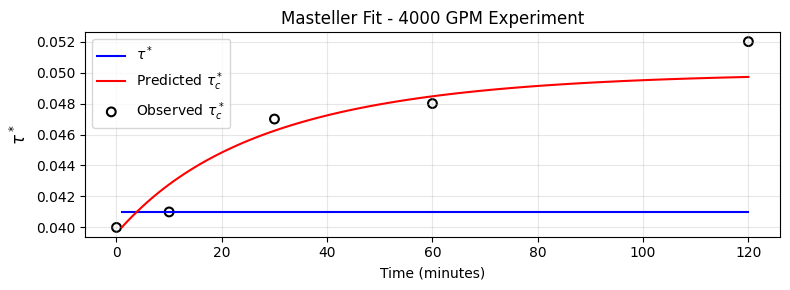

In [9]:
# tau_star is a pd.Series with datetime index
tau_c_pred_series = pd.Series(best_fit_4000, index=tau_star.index)
tau_star_series = pd.Series(tau_star['4000'].values, index=tau_star.index)
obs_tauc_series = pd.Series(tauc_obs_4000_local, index=tauc_measurements.index)

fig, ax = plt.subplots(figsize=(8, 3))

ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=40, 
        linewidth=1.5, label=r'Observed $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time (minutes)', fontsize=10)
ax.legend()
ax.grid(True, alpha=0.3)

plt.title('Masteller Fit - 4000 GPM Experiment', fontsize=12)
plt.tight_layout()
plt.show()

In [9]:
# export predicted tauc time series
predicted_tauc_df = pd.DataFrame({
    'Time': tau_c_pred_series.index,
    'Predicted_tauc': tau_c_pred_series.values
})
predicted_tauc_df.to_csv('results/predicted/4000_local_predicted_tauc.csv', index=False)

### 1.b) 5000 GPM experiments

In [10]:
# use only non-NaN observations for bounds
tauc_obs_5000_local = tauc_measurements['5000'].values
valid_tauc_obs_5000_local = tauc_obs_5000_local[~np.isnan(tauc_obs_5000_local)]
tauc_min_5000_local = valid_tauc_obs_5000_local.min()
tauc_max_5000_local = valid_tauc_obs_5000_local[-2:].mean()

In [12]:
results = calibrate_parameters(
    tau_star=tau_star['5000'],
    event_indices=tauc_measurements.index,
    tau_c_obs=tauc_obs_5000_local,
    dt=1,  # one-minute timestep between τ* samples
    k1_vals=k1_vals,
    k2_vals=k2_vals,
    eps_vals=eps_vals,
    tauc_min=tauc_min_5000_local,
    tauc_max=tauc_max_5000_local,
    gamma=2.5,
)
best = min(results, key=lambda x: x["MAE"])
print("Best-fit parameters:")
print(best)
# convert to dataframe 
results_df = pd.DataFrame(results)
results_df.to_csv('results/iterations/5000_iterations_results.csv', index=False)


Testing k1 = 1.000000e-06 (1/50)
Testing k1 = 1.206793e-06 (2/50)
Testing k1 = 1.456348e-06 (3/50)
Testing k1 = 1.757511e-06 (4/50)
Testing k1 = 2.120951e-06 (5/50)
Testing k1 = 2.559548e-06 (6/50)
Testing k1 = 3.088844e-06 (7/50)
Testing k1 = 3.727594e-06 (8/50)
Testing k1 = 4.498433e-06 (9/50)
Testing k1 = 5.428675e-06 (10/50)
Testing k1 = 6.551286e-06 (11/50)
Testing k1 = 7.906043e-06 (12/50)
Testing k1 = 9.540955e-06 (13/50)
Testing k1 = 1.151395e-05 (14/50)
Testing k1 = 1.389495e-05 (15/50)
Testing k1 = 1.676833e-05 (16/50)
Testing k1 = 2.023590e-05 (17/50)
Testing k1 = 2.442053e-05 (18/50)
Testing k1 = 2.947052e-05 (19/50)
Testing k1 = 3.556480e-05 (20/50)
Testing k1 = 4.291934e-05 (21/50)
Testing k1 = 5.179475e-05 (22/50)
Testing k1 = 6.250552e-05 (23/50)
Testing k1 = 7.543120e-05 (24/50)
Testing k1 = 9.102982e-05 (25/50)
Testing k1 = 1.098541e-04 (26/50)
Testing k1 = 1.325711e-04 (27/50)
Testing k1 = 1.599859e-04 (28/50)
Testing k1 = 1.930698e-04 (29/50)
Testing k1 = 2.329952e-

In [11]:
best_fit_5000 = evolve_tau_c(
    tau_star=tau_star['5000'],
    event_indices=tauc_measurements.index,
    tau_c_obs=tauc_obs_5000_local,
    dt=1,
    k1=0.0012648552168552957,
    k2=0.01,
    epsilon=1,
    tau_c_min=tauc_min_5000_local,
    tau_c_max=tauc_max_5000_local,
    gamma=2.5)

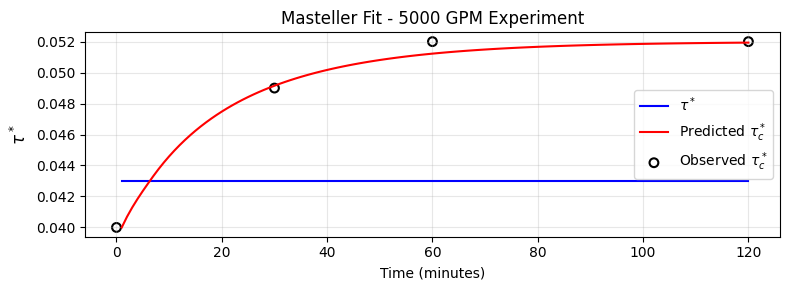

In [12]:
# tau_star is a pd.Series with datetime index
tau_c_pred_series = pd.Series(best_fit_5000, index=tau_star.index)
tau_star_series = pd.Series(tau_star['5000'].values, index=tau_star.index)
obs_tauc_series = pd.Series(tauc_obs_5000_local, index=tauc_measurements.index)

fig, ax = plt.subplots(figsize=(8, 3))

ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=40, 
        linewidth=1.5, label=r'Observed $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time (minutes)', fontsize=10)
ax.legend()
ax.grid(True, alpha=0.3)

plt.title('Masteller Fit - 5000 GPM Experiment', fontsize=12)
plt.tight_layout()
plt.show()

In [13]:
# export predicted tauc time series
predicted_tauc_df = pd.DataFrame({
    'Time': tau_c_pred_series.index,
    'Predicted_tauc': tau_c_pred_series.values
})
predicted_tauc_df.to_csv('results/predicted/5000_local_predicted_tauc.csv', index=False)

### 1.c) 6000 GPM experiments

In [14]:
tauc_obs_6000_local = tauc_measurements['6000'].values
tauc_min_6000_local = tauc_obs_6000_local.min()
tauc_max_6000_local = tauc_obs_6000_local [-2:].mean()

In [17]:
results = calibrate_parameters(
    tau_star=tau_star['6000'],
    event_indices=tauc_measurements.index,
    tau_c_obs=tauc_obs_6000_local,
    dt=1,  # one-minute timestep between τ* samples
    k1_vals=k1_vals,
    k2_vals=k2_vals,
    eps_vals=eps_vals,
    tauc_min=tauc_min_6000_local,
    tauc_max=tauc_max_6000_local,
    gamma=2.5,
)

best = min(results, key=lambda x: x["MAE"])
print("Best-fit parameters:")
print(best)

# convert to dataframe 
results_df = pd.DataFrame(results)
results_df.to_csv('results/iterations/6000_iterations_results.csv', index=False)

Testing k1 = 1.000000e-06 (1/50)
Testing k1 = 1.206793e-06 (2/50)
Testing k1 = 1.456348e-06 (3/50)
Testing k1 = 1.757511e-06 (4/50)
Testing k1 = 2.120951e-06 (5/50)
Testing k1 = 2.559548e-06 (6/50)
Testing k1 = 3.088844e-06 (7/50)
Testing k1 = 3.727594e-06 (8/50)
Testing k1 = 4.498433e-06 (9/50)
Testing k1 = 5.428675e-06 (10/50)
Testing k1 = 6.551286e-06 (11/50)
Testing k1 = 7.906043e-06 (12/50)
Testing k1 = 9.540955e-06 (13/50)
Testing k1 = 1.151395e-05 (14/50)
Testing k1 = 1.389495e-05 (15/50)
Testing k1 = 1.676833e-05 (16/50)
Testing k1 = 2.023590e-05 (17/50)
Testing k1 = 2.442053e-05 (18/50)
Testing k1 = 2.947052e-05 (19/50)
Testing k1 = 3.556480e-05 (20/50)
Testing k1 = 4.291934e-05 (21/50)
Testing k1 = 5.179475e-05 (22/50)
Testing k1 = 6.250552e-05 (23/50)
Testing k1 = 7.543120e-05 (24/50)
Testing k1 = 9.102982e-05 (25/50)
Testing k1 = 1.098541e-04 (26/50)
Testing k1 = 1.325711e-04 (27/50)
Testing k1 = 1.599859e-04 (28/50)
Testing k1 = 1.930698e-04 (29/50)
Testing k1 = 2.329952e-

In [15]:
best_fit_6000 = evolve_tau_c(
    tau_star=tau_star['6000'],
    event_indices=tauc_measurements.index,
    tau_c_obs=tauc_obs_6000_local,
    dt=1,
    k1=0.0015264179671752318,
    k2=1e-06,
    epsilon=10,
    tau_c_min=tauc_min_6000_local,
    tau_c_max=tauc_max_6000_local,
    gamma=2.5)

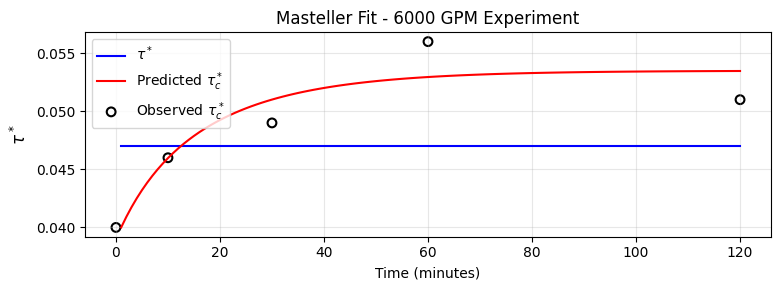

In [16]:
# tau_star is a pd.Series with datetime index
tau_c_pred_series = pd.Series(best_fit_6000, index=tau_star.index)
tau_star_series = pd.Series(tau_star['6000'].values, index=tau_star.index)
obs_tauc_series = pd.Series(tauc_obs_6000_local, index=tauc_measurements.index)

fig, ax = plt.subplots(figsize=(8, 3))

ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=40, 
        linewidth=1.5, label=r'Observed $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time (minutes)', fontsize=10)
ax.legend()
ax.grid(True, alpha=0.3)

plt.title('Masteller Fit - 6000 GPM Experiment', fontsize=12)
plt.tight_layout()
plt.show()

In [17]:
# export predicted tauc time series
predicted_tauc_df = pd.DataFrame({
    'Time': tau_c_pred_series.index,
    'Predicted_tauc': tau_c_pred_series.values
})
predicted_tauc_df.to_csv('results/predicted/6000_local_predicted_tauc.csv', index=False)

### 1.d) 7000 GPM experiments

In [18]:
tauc_obs_7000_local = tauc_measurements['7000'].values
tauc_min_7000_local = tauc_obs_7000_local.min()
tauc_max_7000_local = tauc_obs_7000_local[-2:].mean()

In [22]:
results = calibrate_parameters(
    tau_star=tau_star['7000'],
    event_indices=tauc_measurements.index,
    tau_c_obs=tauc_obs_7000_local,
    dt=1,  # one-minute timestep between τ* samples
    k1_vals=k1_vals,
    k2_vals=k2_vals,
    eps_vals=eps_vals,
    tauc_min=tauc_min_7000_local,
    tauc_max=tauc_max_7000_local,
    gamma=2.5,
)
best = min(results, key=lambda x: x["MAE"])
print("Best-fit parameters:")
print(best)

# convert to dataframe 
results_df = pd.DataFrame(results)
results_df.to_csv('results/iterations/7000_iterations_results.csv', index=False)

Testing k1 = 1.000000e-06 (1/50)
Testing k1 = 1.206793e-06 (2/50)
Testing k1 = 1.456348e-06 (3/50)
Testing k1 = 1.757511e-06 (4/50)
Testing k1 = 2.120951e-06 (5/50)
Testing k1 = 2.559548e-06 (6/50)
Testing k1 = 3.088844e-06 (7/50)
Testing k1 = 3.727594e-06 (8/50)
Testing k1 = 4.498433e-06 (9/50)
Testing k1 = 5.428675e-06 (10/50)
Testing k1 = 6.551286e-06 (11/50)
Testing k1 = 7.906043e-06 (12/50)
Testing k1 = 9.540955e-06 (13/50)
Testing k1 = 1.151395e-05 (14/50)
Testing k1 = 1.389495e-05 (15/50)
Testing k1 = 1.676833e-05 (16/50)
Testing k1 = 2.023590e-05 (17/50)
Testing k1 = 2.442053e-05 (18/50)
Testing k1 = 2.947052e-05 (19/50)
Testing k1 = 3.556480e-05 (20/50)
Testing k1 = 4.291934e-05 (21/50)
Testing k1 = 5.179475e-05 (22/50)
Testing k1 = 6.250552e-05 (23/50)
Testing k1 = 7.543120e-05 (24/50)
Testing k1 = 9.102982e-05 (25/50)
Testing k1 = 1.098541e-04 (26/50)
Testing k1 = 1.325711e-04 (27/50)
Testing k1 = 1.599859e-04 (28/50)
Testing k1 = 1.930698e-04 (29/50)
Testing k1 = 2.329952e-

In [19]:
best_fit_7000 = evolve_tau_c(
    tau_star=tau_star['7000'],
    event_indices=tauc_measurements.index,
    tau_c_obs=tauc_obs_7000_local,
    dt=1,
    k1=0.01,
    k2=1e-06,
    epsilon=10,
    tau_c_min=tauc_min_7000_local,
    tau_c_max=tauc_max_7000_local,
    gamma=2.5)

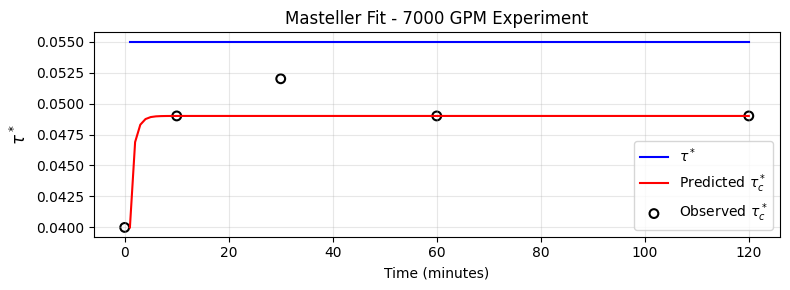

In [20]:
# tau_star is a pd.Series with datetime index
tau_c_pred_series = pd.Series(best_fit_7000, index=tau_star.index)
tau_star_series = pd.Series(tau_star['7000'].values, index=tau_star.index)
obs_tauc_series = pd.Series(tauc_obs_7000_local, index=tauc_measurements.index)

fig, ax = plt.subplots(figsize=(8, 3))

ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=40, 
        linewidth=1.5, label=r'Observed $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time (minutes)', fontsize=10)
ax.legend()
ax.grid(True, alpha=0.3)

plt.title('Masteller Fit - 7000 GPM Experiment', fontsize=12)
plt.tight_layout()
plt.show()

In [21]:
# export predicted tauc time series
predicted_tauc_df = pd.DataFrame({
    'Time': tau_c_pred_series.index,
    'Predicted_tauc': tau_c_pred_series.values
})
predicted_tauc_df.to_csv('results/predicted/7000_local_predicted_tauc.csv', index=False)

### Plot all together

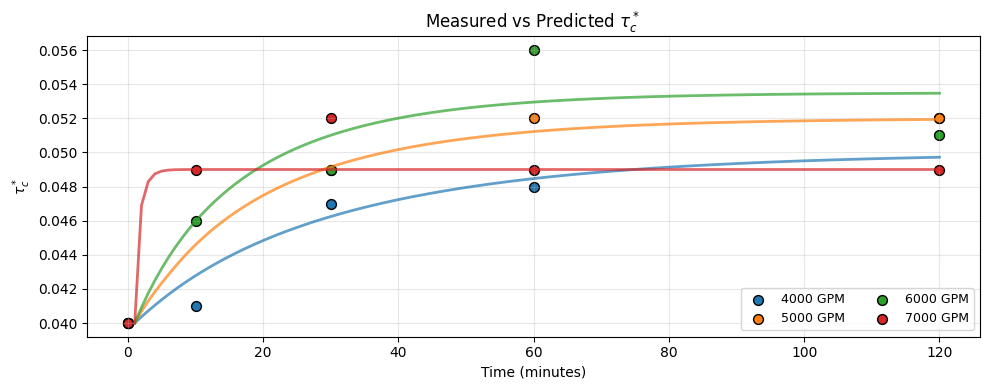

In [22]:
flows = ['4000', '5000', '6000', '7000']
colors = dict(zip(flows, plt.cm.tab10.colors[:4]))

pred_by_flow = {
    '4000': best_fit_4000,
    '5000': best_fit_5000,
    '6000': best_fit_6000,
    '7000': best_fit_7000,
}

fig, ax = plt.subplots(figsize=(10, 4))

for flow in flows:
    if flow not in pred_by_flow or pred_by_flow[flow] is None:
        continue

    tau_series = tau_star[flow]
    pred_full = np.asarray(pred_by_flow[flow], dtype=float)

    # plot prediction (1-minute)
    c = colors[flow]
    ax.plot(tau_series.index, pred_full, color=c, linewidth=2, alpha=0.7)

    # plot measured values 
    obs = tauc_measurements[flow].to_numpy(dtype=float)
    obs_time = tauc_measurements.index.to_numpy()
    valid_obs_mask = ~np.isnan(obs)
    ax.scatter(
        obs_time[valid_obs_mask],
        obs[valid_obs_mask],
        color=c,
        s=50,
        label=f'{flow} GPM',
        edgecolors='black',
    )

ax.set_xlabel('Time (minutes)')
ax.set_ylabel(r'$\tau_c^*$')
ax.set_title(r'Measured vs Predicted $\tau_c^*$ ')
ax.grid(True, alpha=0.3)
ax.legend(ncol=2, fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()

## 2) Calibration with global maximum
tauc_min and tauc_max are the same for all three experiments

In [23]:
# one global min/max across all experiments (ignores NaNs)
tauc_min_global_all = np.nanmin(tauc_measurements.to_numpy(dtype=float))
tauc_max_global_all = np.nanmax(tauc_measurements.to_numpy(dtype=float))

print('global min and max are:', tauc_min_global_all, tauc_max_global_all)

global min and max are: 0.04 0.056


### 2.a) 4000 GPM experiments

In [24]:
# observed τ*c for one selected experiment
tauc_obs_4000_global = tauc_measurements['4000'].to_numpy(dtype=float)

In [28]:
results = calibrate_parameters(
    tau_star=tau_star['4000'],
    event_indices=tauc_measurements.index,
    tau_c_obs=tauc_measurements['4000'].values,
    dt=1,  # one-minute timestep between τ* samples
    k1_vals=k1_vals,
    k2_vals=k2_vals,
    eps_vals=eps_vals,
    tauc_min=tauc_min_global_all,
    tauc_max=tauc_max_global_all,
    gamma=2.5,
)
best = min(results, key=lambda x: x["MAE"])
print("Best-fit parameters:")
print(best)
# convert to dataframe 
results_df = pd.DataFrame(results)
# export as csv
results_df.to_csv('results/iterations/4000_iterations_globalmax.csv', index=False)


Testing k1 = 1.000000e-06 (1/50)
Testing k1 = 1.206793e-06 (2/50)
Testing k1 = 1.456348e-06 (3/50)
Testing k1 = 1.757511e-06 (4/50)
Testing k1 = 2.120951e-06 (5/50)
Testing k1 = 2.559548e-06 (6/50)
Testing k1 = 3.088844e-06 (7/50)
Testing k1 = 3.727594e-06 (8/50)
Testing k1 = 4.498433e-06 (9/50)
Testing k1 = 5.428675e-06 (10/50)
Testing k1 = 6.551286e-06 (11/50)
Testing k1 = 7.906043e-06 (12/50)
Testing k1 = 9.540955e-06 (13/50)
Testing k1 = 1.151395e-05 (14/50)
Testing k1 = 1.389495e-05 (15/50)
Testing k1 = 1.676833e-05 (16/50)
Testing k1 = 2.023590e-05 (17/50)
Testing k1 = 2.442053e-05 (18/50)
Testing k1 = 2.947052e-05 (19/50)
Testing k1 = 3.556480e-05 (20/50)
Testing k1 = 4.291934e-05 (21/50)
Testing k1 = 5.179475e-05 (22/50)
Testing k1 = 6.250552e-05 (23/50)
Testing k1 = 7.543120e-05 (24/50)
Testing k1 = 9.102982e-05 (25/50)
Testing k1 = 1.098541e-04 (26/50)
Testing k1 = 1.325711e-04 (27/50)
Testing k1 = 1.599859e-04 (28/50)
Testing k1 = 1.930698e-04 (29/50)
Testing k1 = 2.329952e-

In [25]:
best_fit_4000_global = evolve_tau_c(
    tau_star=tau_star['4000'],
    event_indices=tauc_measurements.index,
    tau_c_obs=tauc_obs_4000_local,
    dt=1,
    k1=0.0004094915062380423,
    k2=2.1209508879201924e-06,
    epsilon=4.909090909090909,
    tau_c_min=tauc_min_global_all,
    tau_c_max=tauc_max_global_all,
    gamma=2.5)

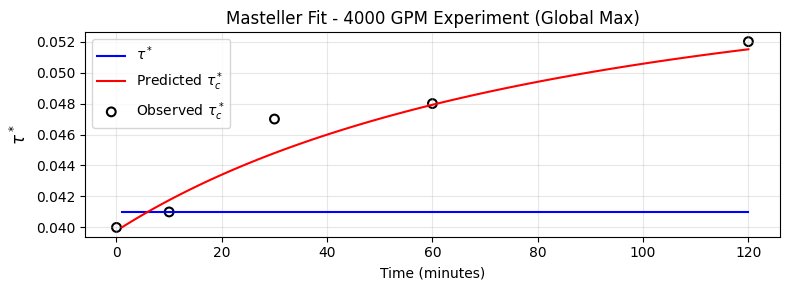

In [26]:
# tau_star is a pd.Series with datetime index
tau_c_pred_series = pd.Series(best_fit_4000_global, index=tau_star.index)
tau_star_series = pd.Series(tau_star['4000'].values, index=tau_star.index)
obs_tauc_series = pd.Series(tauc_obs_4000_global, index=tauc_measurements.index)

fig, ax = plt.subplots(figsize=(8, 3))

ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=40, 
        linewidth=1.5, label=r'Observed $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time (minutes)', fontsize=10)
ax.legend()
ax.grid(True, alpha=0.3)

plt.title('Masteller Fit - 4000 GPM Experiment (Global Max)', fontsize=12)
plt.tight_layout()
plt.show()

### 2.b) 5000 GPM experiments

In [31]:
tauc_obs_5000_global = tauc_measurements['5000'].values

In [32]:
results = calibrate_parameters(
    tau_star=tau_star['5000'],
    event_indices=tauc_measurements.index,
    tau_c_obs=tauc_obs_5000_local,
    dt=1,  # one-minute timestep between τ* samples
    k1_vals=k1_vals,
    k2_vals=k2_vals,
    eps_vals=eps_vals,
    tauc_min=tauc_min_global_all,
    tauc_max=tauc_max_global_all,
    gamma=2.5,
)
best = min(results, key=lambda x: x["MAE"])
print("Best-fit parameters:")
print(best)

# convert to dataframe 
results_df = pd.DataFrame(results)
# export as csv
results_df.to_csv('results/iterations/5000_iterations_globalmax.csv', index=False)

Testing k1 = 1.000000e-06 (1/50)
Testing k1 = 1.206793e-06 (2/50)
Testing k1 = 1.456348e-06 (3/50)
Testing k1 = 1.757511e-06 (4/50)
Testing k1 = 2.120951e-06 (5/50)
Testing k1 = 2.559548e-06 (6/50)
Testing k1 = 3.088844e-06 (7/50)
Testing k1 = 3.727594e-06 (8/50)
Testing k1 = 4.498433e-06 (9/50)
Testing k1 = 5.428675e-06 (10/50)
Testing k1 = 6.551286e-06 (11/50)
Testing k1 = 7.906043e-06 (12/50)
Testing k1 = 9.540955e-06 (13/50)
Testing k1 = 1.151395e-05 (14/50)
Testing k1 = 1.389495e-05 (15/50)
Testing k1 = 1.676833e-05 (16/50)
Testing k1 = 2.023590e-05 (17/50)
Testing k1 = 2.442053e-05 (18/50)
Testing k1 = 2.947052e-05 (19/50)
Testing k1 = 3.556480e-05 (20/50)
Testing k1 = 4.291934e-05 (21/50)
Testing k1 = 5.179475e-05 (22/50)
Testing k1 = 6.250552e-05 (23/50)
Testing k1 = 7.543120e-05 (24/50)
Testing k1 = 9.102982e-05 (25/50)
Testing k1 = 1.098541e-04 (26/50)
Testing k1 = 1.325711e-04 (27/50)
Testing k1 = 1.599859e-04 (28/50)
Testing k1 = 1.930698e-04 (29/50)
Testing k1 = 2.329952e-

In [33]:
best_fit_5000_global = evolve_tau_c(
    tau_star=tau_star['5000'],
    event_indices=tauc_measurements.index,
    tau_c_obs=tauc_obs_5000_local,
    dt=1,
    k1=0.000868511373751352,
    k2=1e-06,
    epsilon=7.818181818181818,
    tau_c_min=tauc_min_global_all,
    tau_c_max=tauc_max_global_all,
    gamma=2.5)

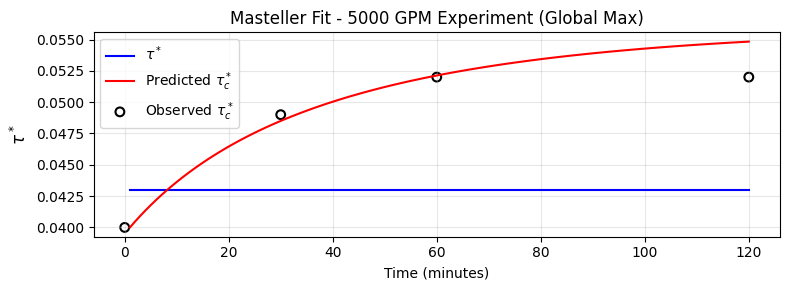

In [ ]:
# tau_star is a pd.Series with datetime index
tau_c_pred_series = pd.Series(best_fit_5000_global, index=tau_star.index)
tau_star_series = pd.Series(tau_star['5000'].values, index=tau_star.index)
obs_tauc_series = pd.Series(tauc_obs_5000_global, index=tauc_measurements.index)

fig, ax = plt.subplots(figsize=(8, 3))

ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=40, 
        linewidth=1.5, label=r'Observed $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time (minutes)', fontsize=10)
ax.legend()
ax.grid(True, alpha=0.3)

plt.title('Masteller Fit - 5000 GPM Experiment (Global Max)', fontsize=12)
plt.tight_layout()
plt.show()

### 2.c) 6000 GPM experiments

In [34]:
tauc_obs_6000_global = tauc_measurements['6000'].values

In [35]:
results = calibrate_parameters(
    tau_star=tau_star['6000'],
    event_indices=tauc_measurements.index,
    tau_c_obs=tauc_measurements['6000'].values,
    dt=1,  # one-minute timestep between τ* samples
    k1_vals=k1_vals,
    k2_vals=k2_vals,
    eps_vals=eps_vals,
    tauc_min=tauc_min_global_all,
    tauc_max=tauc_max_global_all,
    gamma=2.5,
)
best = min(results, key=lambda x: x["MAE"])
print("Best-fit parameters:")
print(best)
# convert to dataframe 
results_df = pd.DataFrame(results)
# export as csv
results_df.to_csv('results/iterations/6000_iterations_globalmax.csv', index=False)

Testing k1 = 1.000000e-06 (1/50)
Testing k1 = 1.206793e-06 (2/50)
Testing k1 = 1.456348e-06 (3/50)
Testing k1 = 1.757511e-06 (4/50)
Testing k1 = 2.120951e-06 (5/50)
Testing k1 = 2.559548e-06 (6/50)
Testing k1 = 3.088844e-06 (7/50)
Testing k1 = 3.727594e-06 (8/50)
Testing k1 = 4.498433e-06 (9/50)
Testing k1 = 5.428675e-06 (10/50)
Testing k1 = 6.551286e-06 (11/50)
Testing k1 = 7.906043e-06 (12/50)
Testing k1 = 9.540955e-06 (13/50)
Testing k1 = 1.151395e-05 (14/50)
Testing k1 = 1.389495e-05 (15/50)
Testing k1 = 1.676833e-05 (16/50)
Testing k1 = 2.023590e-05 (17/50)
Testing k1 = 2.442053e-05 (18/50)
Testing k1 = 2.947052e-05 (19/50)
Testing k1 = 3.556480e-05 (20/50)
Testing k1 = 4.291934e-05 (21/50)
Testing k1 = 5.179475e-05 (22/50)
Testing k1 = 6.250552e-05 (23/50)
Testing k1 = 7.543120e-05 (24/50)
Testing k1 = 9.102982e-05 (25/50)
Testing k1 = 1.098541e-04 (26/50)
Testing k1 = 1.325711e-04 (27/50)
Testing k1 = 1.599859e-04 (28/50)
Testing k1 = 1.930698e-04 (29/50)
Testing k1 = 2.329952e-

In [36]:
best_fit_6000_global = evolve_tau_c(
    tau_star=tau_star['6000'],
    event_indices=tauc_measurements.index,
    tau_c_obs=tauc_obs_6000_local,
    dt=1,
    k1=0.0015264179671752318,
    k2=0.0026826957952797246,
    epsilon=1.090909091,
    tau_c_min=tauc_min_global_all,
    tau_c_max=tauc_max_global_all,
    gamma=2.5)

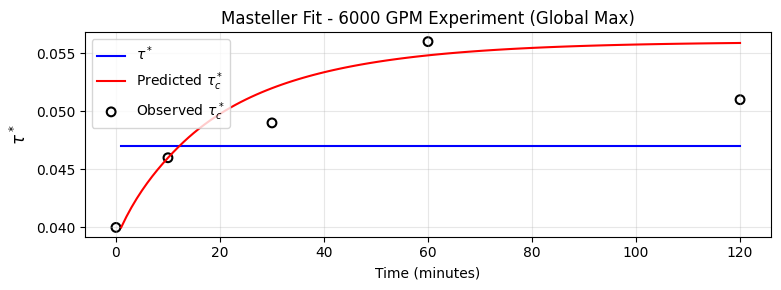

In [37]:
# tau_star is a pd.Series with datetime index
tau_c_pred_series = pd.Series(best_fit_6000_global, index=tau_star.index)
tau_star_series = pd.Series(tau_star['6000'].values, index=tau_star.index)
obs_tauc_series = pd.Series(tauc_obs_6000_global, index=tauc_measurements.index)

fig, ax = plt.subplots(figsize=(8, 3))

ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=40, 
        linewidth=1.5, label=r'Observed $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time (minutes)', fontsize=10)
ax.legend()
ax.grid(True, alpha=0.3)

plt.title('Masteller Fit - 6000 GPM Experiment (Global Max)', fontsize=12)
plt.tight_layout()
plt.show()

### 2.d) 7000 GPM experiments

In [42]:
tauc_obs_7000_global = tauc_measurements['7000'].values

In [ ]:
results = calibrate_parameters(
    tau_star=tau_star['7000'],
    event_indices=tauc_measurements.index,
    tau_c_obs=tauc_obs_7000_global,
    dt=1,  # one-minute timestep between τ* samples
    k1_vals=k1_vals,
    k2_vals=k2_vals,
    eps_vals=eps_vals,
    tauc_min=tauc_min_global_all,
    tauc_max=tauc_max_global_all,
    gamma=2.5,
)
best = min(results, key=lambda x: x["MAE"])
print("Best-fit parameters:")
print(best)

# convert to dataframe 
results_df = pd.DataFrame(results)
# export as csv
results_df.to_csv('results/iterations/7000_iterations_globalmax.csv', index=False)

Testing k1 = 1.000000e-06 (1/50)
Testing k1 = 1.206793e-06 (2/50)
Testing k1 = 1.456348e-06 (3/50)
Testing k1 = 1.757511e-06 (4/50)
Testing k1 = 2.120951e-06 (5/50)
Testing k1 = 2.559548e-06 (6/50)
Testing k1 = 3.088844e-06 (7/50)
Testing k1 = 3.727594e-06 (8/50)
Testing k1 = 4.498433e-06 (9/50)
Testing k1 = 5.428675e-06 (10/50)
Testing k1 = 6.551286e-06 (11/50)
Testing k1 = 7.906043e-06 (12/50)
Testing k1 = 9.540955e-06 (13/50)
Testing k1 = 1.151395e-05 (14/50)
Testing k1 = 1.389495e-05 (15/50)
Testing k1 = 1.676833e-05 (16/50)
Testing k1 = 2.023590e-05 (17/50)
Testing k1 = 2.442053e-05 (18/50)
Testing k1 = 2.947052e-05 (19/50)
Testing k1 = 3.556480e-05 (20/50)
Testing k1 = 4.291934e-05 (21/50)
Testing k1 = 5.179475e-05 (22/50)
Testing k1 = 6.250552e-05 (23/50)
Testing k1 = 7.543120e-05 (24/50)
Testing k1 = 9.102982e-05 (25/50)
Testing k1 = 1.098541e-04 (26/50)
Testing k1 = 1.325711e-04 (27/50)
Testing k1 = 1.599859e-04 (28/50)
Testing k1 = 1.930698e-04 (29/50)
Testing k1 = 2.329952e-

In [43]:
best_fit_7000_global = evolve_tau_c(
    tau_star=tau_star['7000'],
    event_indices=tauc_measurements.index,
    tau_c_obs=tauc_obs_7000_global,
    dt=1,
    k1=0.0026826957952797246,
    k2=0.01,
    epsilon=1,
    tau_c_min=tauc_min_global_all,
    tau_c_max=tauc_max_global_all,
    gamma=2.5)

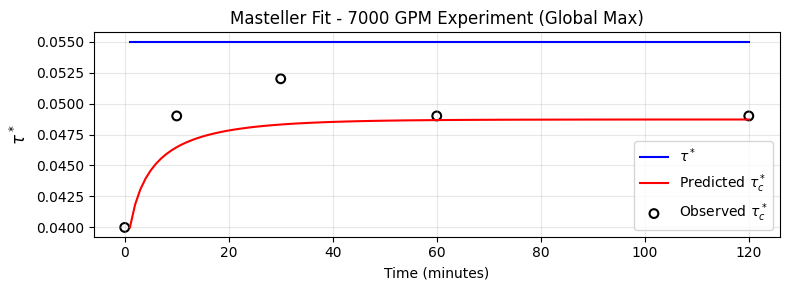

In [44]:
# tau_star is a pd.Series with datetime index
tau_c_pred_series = pd.Series(best_fit_7000_global, index=tau_star.index)
tau_star_series = pd.Series(tau_star['7000'].values, index=tau_star.index)
obs_tauc_series = pd.Series(tauc_obs_7000_global, index=tauc_measurements.index)

fig, ax = plt.subplots(figsize=(8, 3))

ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=40, 
        linewidth=1.5, label=r'Observed $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time (minutes)', fontsize=10)
ax.legend()
ax.grid(True, alpha=0.3)

plt.title('Masteller Fit - 7000 GPM Experiment (Global Max)', fontsize=12)
plt.tight_layout()
plt.show()

### Plot all together

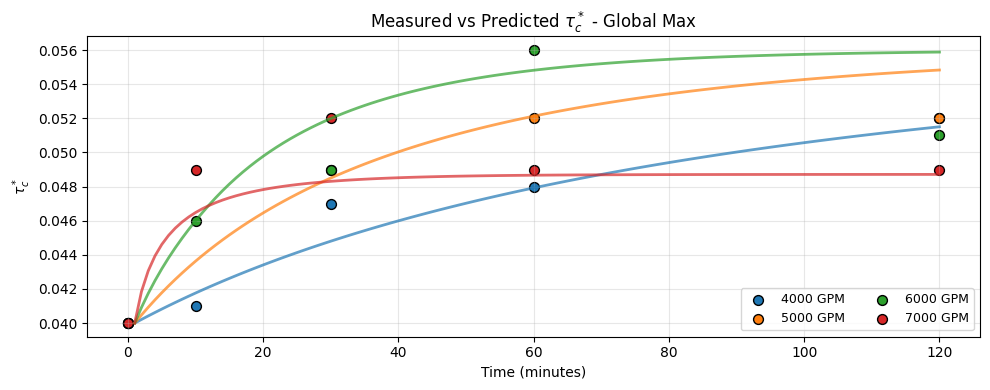

In [45]:
flows = ['4000', '5000', '6000', '7000']
colors = dict(zip(flows, plt.cm.tab10.colors[:4]))

pred_by_flow = {
    '4000': best_fit_4000_global,
    '5000': best_fit_5000_global,
    '6000': best_fit_6000_global,
    '7000': best_fit_7000_global,
}

fig, ax = plt.subplots(figsize=(10, 4))

for flow in flows:
    if flow not in pred_by_flow or pred_by_flow[flow] is None:
        continue

    tau_series = tau_star[flow]
    pred_full = np.asarray(pred_by_flow[flow], dtype=float)

    # plot prediction (1-minute)
    c = colors[flow]
    ax.plot(tau_series.index, pred_full, color=c, linewidth=2, alpha=0.7)

    # plot measured values 
    obs = tauc_measurements[flow].to_numpy(dtype=float)
    obs_time = tauc_measurements.index.to_numpy()
    valid_obs_mask = ~np.isnan(obs)
    ax.scatter(
        obs_time[valid_obs_mask],
        obs[valid_obs_mask],
        color=c,
        s=50,
        label=f'{flow} GPM',
        edgecolors='black',
    )

ax.set_xlabel('Time (minutes)')
ax.set_ylabel(r'$\tau_c^*$')
ax.set_title(r'Measured vs Predicted $\tau_c^*$ - Global Max', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(ncol=2, fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()

## Estimating tauc_max convergence times

In [46]:
def time_to_max_beyond_120(
    tau_c0, tau_future, tauc_min, tauc_max, k1, k2, epsilon,
    dt=1.0, gamma=2.5, max_minutes=20000, atol=1e-10
):
    """
    Simulate forward from current tau_c0 under constant future tau* = tau_future.
    Returns minutes to reach tauc_max, or np.nan if never reached within max_minutes.
    """
    tc = float(tau_c0)

    for m in range(1, max_minutes + 1):
        # Treat tiny numerical gap as reached
        if tc >= tauc_max - atol:
            return m - 1

        tc_clip = np.clip(tc, tauc_min, tauc_max)

        # avoid divide-by-zero
        if tc_clip <= 0:
            return np.nan

        B = (tauc_max - tc_clip) / (tauc_max - tauc_min)
        R = tau_future / tc_clip

        strengthen = k1 * B / (1.0 + R**(-gamma))
        weaken = k2 * (1.0 - B) * (R - 1.0)**epsilon if R > 1.0 else 0.0

        tc = tc_clip + (strengthen - weaken) * dt

    return np.nan

def crossing_table_after_120(
    tau_star, tauc_measurements, best_fit_map, params_by_flow,
    tauc_min, tauc_max, label="local"
):
    """
    Estimate convergence time to tauc_max.
    
    Parameters provided are used as-is:
    - best_fit_map: {flow: array} of modeled tau_c values at 120 min
    - params_by_flow: {flow: {k1, k2, epsilon}} calibration parameters
    - tauc_min, tauc_max: bounds to use
    - label: string label for the mode (e.g., "local" or "global")
    
    Returns DataFrame with one row per flow.
    """
    rows = []
    
    for flow, p in params_by_flow.items():
        tau_c0 = float(best_fit_map[flow][-1])  # modeled at 120 min

        ts = tau_star[flow].to_numpy(dtype=float)
        tau_constant = float(ts[-1])

        obs = tauc_measurements[flow].to_numpy(dtype=float)
        obs_valid = obs[~np.isnan(obs)]
        tauc_measured = float(obs_valid[-1])

        # Find when it first reaches target_max
        model_evolution = np.asarray(best_fit_map[flow], dtype=float)
        time_reached = None
        for t_idx, tau_c_val in enumerate(model_evolution):
            if not np.isnan(tau_c_val) and tau_c_val >= tauc_max - 1e-10:
                time_reached = t_idx
                break
        
        # If not reached by 120 min, continue simulation
        if time_reached is None:
            add_min = time_to_max_beyond_120(
                tau_c0=tau_c0,
                tau_future=tau_constant,
                tauc_min=tauc_min,
                tauc_max=tauc_max,
                k1=p["k1"], k2=p["k2"], epsilon=p["epsilon"],
                dt=1.0, gamma=2.5, max_minutes=20000
            )
            time_reached = 120 + add_min if not np.isnan(add_min) else np.nan

        rows.append({
            "flow": flow,
            "mode": label,
            "target_max": tauc_max,
            "applied_tau": tau_constant,
            "tauc_measured_at_120": tauc_measured,
            "tauc_modeled_at_120": tau_c0,
            "minutes_to_reach_max": time_reached
        })

    return pd.DataFrame(rows)


In [47]:
# LOCAL calibration: local best_fit arrays, local parameters, local bounds
tauc_min_local = 0.04  # from Section 1
tauc_max_local_vals = [
    tauc_measurements['4000'].dropna().iloc[-2:].mean(),
    tauc_measurements['5000'].dropna().iloc[-2:].mean(),
    tauc_measurements['6000'].dropna().iloc[-2:].mean(),
    tauc_measurements['7000'].dropna().iloc[-2:].mean()
]

params_by_flow_local = {
    "4000": {"k1": 0.0007196856730011514, "k2": 0.01, "epsilon": 1},
    "5000": {"k1": 0.0012648552168552957, "k2": 0.01, "epsilon": 1},
    "6000": {"k1": 0.0015264179671752318, "k2": 1e-06, "epsilon": 10},
    "7000": {"k1": 0.01, "k2": 1e-06, "epsilon": 10}
}

best_fit_map_local = {
    "4000": best_fit_4000,
    "5000": best_fit_5000,
    "6000": best_fit_6000,
    "7000": best_fit_7000
}

# Compute local table (each flow uses its own observed max)
future_cross_local_list = []
for flow in ["4000", "5000", "6000", "7000"]:
    tauc_max_local = tauc_measurements[flow].dropna().iloc[-2:].mean()
    result = crossing_table_after_120(
        tau_star=tau_star,
        tauc_measurements=tauc_measurements,
        best_fit_map=best_fit_map_local,
        params_by_flow={flow: params_by_flow_local[flow]},
        tauc_min=tauc_min_local,
        tauc_max=tauc_max_local,
        label="local"
    )
    future_cross_local_list.append(result)

future_cross_local = pd.concat(future_cross_local_list, ignore_index=True)

# GLOBAL calibration: global best_fit arrays, global parameters, global bounds
tauc_min_global = np.nanmin(tauc_measurements.to_numpy(dtype=float))
tauc_max_global = np.nanmax(tauc_measurements.to_numpy(dtype=float))

params_by_flow_global = {
    "4000": {"k1": 0.0004094915062380423, "k2": 2.1209508879201924e-06, "epsilon": 4.909090909090909},
    "5000": {"k1": 0.000868511373751352, "k2": 1e-06, "epsilon": 7.818181818181818},
    "6000": {"k1": 0.0015264179671752318, "k2": 0.0026826957952797246, "epsilon": 1.090909091},
    "7000": {"k1": 0.0026826957952797246, "k2": 0.01, "epsilon": 1.0}
}

best_fit_map_global = {
    "4000": best_fit_4000_global,
    "5000": best_fit_5000_global,
    "6000": best_fit_6000_global,
    "7000": best_fit_7000_global
}

future_cross_global = crossing_table_after_120(
    tau_star=tau_star,
    tauc_measurements=tauc_measurements,
    best_fit_map=best_fit_map_global,
    params_by_flow=params_by_flow_global,
    tauc_min=tauc_min_global,
    tauc_max=tauc_max_global,
    label="global"
)

print("LOCAL MODE (each flow to its own observed max):")
display(future_cross_local)
print("\nGLOBAL MODE (each flow to global max):")
display(future_cross_global)

LOCAL MODE (each flow to its own observed max):


,flow,mode,target_max,applied_tau,tauc_measured_at_120,tauc_modeled_at_120,minutes_to_reach_max
0,4000,local,0.0500,0.041,0.052,0.049719,658
1,5000,local,0.0520,0.043,0.052,0.051936,445
2,6000,local,0.0535,0.047,0.051,0.053471,379
3,7000,local,0.0490,0.055,0.049,0.049000,18



GLOBAL MODE (each flow to global max):


,flow,mode,target_max,applied_tau,tauc_measured_at_120,tauc_modeled_at_120,minutes_to_reach_max
0,4000,global,0.056,0.041,0.052,0.051505,2285.0
1,5000,global,0.056,0.043,0.052,0.054832,991.0
2,6000,global,0.056,0.047,0.051,0.055884,487.0
3,7000,global,0.056,0.055,0.049,0.048713,NaN


In [49]:
# Check the full evolution paths, not just the endpoints
print("=" * 60)
print("CHECKING: Full array statistics (not just final value)")
print("=" * 60)

for flow in ["5000"]:  # focus on 5000
    local_arr = np.asarray(best_fit_map_local[flow], dtype=float)
    global_arr = np.asarray(best_fit_map_global[flow], dtype=float)
    
    print(f"\n{flow} GPM arrays:")
    print(f"  Local array:  min={np.nanmin(local_arr):.6f}, max={np.nanmax(local_arr):.6f}, final={local_arr[-1]:.6f}, length={len(local_arr)}")
    print(f"  Global array: min={np.nanmin(global_arr):.6f}, max={np.nanmax(global_arr):.6f}, final={global_arr[-1]:.6f}, length={len(global_arr)}")
    
    # Compare values over time
    print(f"\n  Comparison at key minutes:")
    for idx in [0, 30, 60, 90, 119]:
        print(f"    t={idx}: local={local_arr[idx]:.6f}, global={global_arr[idx]:.6f}, diff={abs(local_arr[idx] - global_arr[idx]):.6f}")

CHECKING: Full array statistics (not just final value)

5000 GPM arrays:
  Local array:  min=0.040000, max=0.051936, final=0.051936, length=120
  Global array: min=0.040000, max=0.054832, final=0.054832, length=120

  Comparison at key minutes:
    t=0: local=0.040000, global=0.040000, diff=0.000000
    t=30: local=0.049277, global=0.048675, diff=0.000602
    t=60: local=0.051256, global=0.052207, diff=0.000952
    t=90: local=0.051788, global=0.053939, diff=0.002151
    t=119: local=0.051936, global=0.054832, diff=0.002895


## 3) Single parameter calibration

In [13]:
import itertools
import numpy as np
import pandas as pd

def calibrate_parameters_all_flows(
    tau_star,                # dataFrame with columns like ['4000','5000','6000','7000']
    tauc_measurements,       # dataFrame with observed tau_c* at event times
    flows,                   # list of flow column names
    dt,
    k1_vals,
    k2_vals,
    eps_vals,
    gamma=2.5,
    bounds_mode="local",     # "local" or "global"
    aggregation="mean_of_flows",  # "mean_of_flows" or "pooled"
    store_all_results=True,
    verbose=True,
):
    """
    Find one shared (k1, k2, epsilon) that minimizes MAE across all selected flows.

    aggregation:
      - "mean_of_flows": each flow contributes equally (mean of per-flow MAEs)
      - "pooled": all valid points pooled together (flow with more valid points weighs more)
    """
    if aggregation not in {"mean_of_flows", "pooled"}:
        raise ValueError("aggregation must be 'mean_of_flows' or 'pooled'")
    if bounds_mode not in {"local", "global"}:
        raise ValueError("bounds_mode must be 'local' or 'global'")

    event_indices = tauc_measurements.index
    flow_data = {}

    # precompute valid observations and bounds per flow
    if bounds_mode == "global":
        global_min = np.nanmin(tauc_measurements[flows].to_numpy(dtype=float))
        global_max = np.nanmax(tauc_measurements[flows].to_numpy(dtype=float))

    for flow in flows:
        tau_series = tau_star[flow]
        obs_full = tauc_measurements[flow].to_numpy(dtype=float)

        valid_mask = ~np.isnan(obs_full)
        if not np.any(valid_mask):
            raise ValueError(f"Flow {flow} has no valid observations.")

        # map event labels -> integer positions in tau_star index
        event_pos_all = tau_series.index.get_indexer(np.asarray(event_indices))
        missing_mask = event_pos_all < 0
        if np.any(missing_mask):
            event_labels = np.asarray(event_indices)
            if np.issubdtype(event_labels.dtype, np.number):
                before_start = missing_mask & (event_labels < tau_series.index.min())
                event_pos_all[before_start] = 0

        if np.any(event_pos_all < 0):
            missing = np.asarray(event_indices)[event_pos_all < 0]
            raise ValueError(f"Flow {flow}: some event indices are not in tau_star index: {missing}")

        event_pos_valid = event_pos_all[valid_mask]
        obs_valid = obs_full[valid_mask]

        if bounds_mode == "local":
            tauc_min = np.nanmin(obs_full)
            tauc_max = np.nanmean(obs_valid[-2:]) if len(obs_valid) >= 2 else obs_valid[-1]
        else:
            tauc_min, tauc_max = global_min, global_max

        flow_data[flow] = {
            "tau_series": tau_series,
            "obs_full": obs_full,
            "event_pos_valid": event_pos_valid,
            "obs_valid": obs_valid,
            "tauc_min": float(tauc_min),
            "tauc_max": float(tauc_max),
        }

    combos = list(itertools.product(k1_vals, k2_vals, eps_vals))
    n_total = len(combos)

    best = None
    all_rows = []

    for i, (k1, k2, eps) in enumerate(combos, start=1):
        mae_by_flow = {}
        abs_err_all = []

        for flow in flows:
            fd = flow_data[flow]
            tau_c_model = evolve_tau_c(
                tau_star=fd["tau_series"],
                event_indices=event_indices,
                tau_c_obs=fd["obs_full"],
                dt=dt,
                k1=k1,
                k2=k2,
                epsilon=eps,
                tau_c_min=fd["tauc_min"],
                tau_c_max=fd["tauc_max"],
                gamma=gamma,
            )

            pred = tau_c_model[fd["event_pos_valid"]]
            abs_err = np.abs(pred - fd["obs_valid"])
            mae_flow = float(np.mean(abs_err))
            mae_by_flow[flow] = mae_flow
            abs_err_all.append(abs_err)

        if aggregation == "mean_of_flows":
            total_mae = float(np.mean([mae_by_flow[f] for f in flows]))
        else:
            total_mae = float(np.mean(np.concatenate(abs_err_all)))

        row = {
            "k1": float(k1),
            "k2": float(k2),
            "epsilon": float(eps),
            "MAE_total": total_mae,
        }
        for flow in flows:
            row[f"MAE_{flow}"] = mae_by_flow[flow]

        if store_all_results:
            all_rows.append(row)

        if (best is None) or (total_mae < best["MAE_total"]):
            best = row.copy()

        if verbose and (i % max(1, n_total // 20) == 0 or i == n_total):
            print(f"Progress: {i}/{n_total} ({100*i/n_total:.1f}%) | best MAE={best['MAE_total']:.6f}")

    results_df = pd.DataFrame(all_rows) if store_all_results else None
    return best, results_df


def run_best_fit_all_flows(
    tau_star,
    tauc_measurements,
    flows,
    best_params,
    dt=1.0,
    gamma=2.5,
    bounds_mode="local",
):
    """
    Run evolve_tau_c for each flow using one shared best parameter set.
    Returns dict: {flow: modeled_tau_c_array}
    """
    k1 = best_params["k1"]
    k2 = best_params["k2"]
    eps = best_params["epsilon"]

    event_indices = tauc_measurements.index
    preds = {}

    if bounds_mode == "global":
        global_min = np.nanmin(tauc_measurements[flows].to_numpy(dtype=float))
        global_max = np.nanmax(tauc_measurements[flows].to_numpy(dtype=float))

    for flow in flows:
        obs_full = tauc_measurements[flow].to_numpy(dtype=float)
        valid_obs = obs_full[~np.isnan(obs_full)]

        if bounds_mode == "local":
            tauc_min = np.nanmin(obs_full)
            tauc_max = np.nanmean(valid_obs[-2:]) if len(valid_obs) >= 2 else valid_obs[-1]
        else:
            tauc_min, tauc_max = global_min, global_max

        preds[flow] = evolve_tau_c(
            tau_star=tau_star[flow],
            event_indices=event_indices,
            tau_c_obs=obs_full,
            dt=dt,
            k1=k1,
            k2=k2,
            epsilon=eps,
            tau_c_min=float(tauc_min),
            tau_c_max=float(tauc_max),
            gamma=gamma,
        )

    return preds

Local Max

In [22]:
flows = ["4000", "5000", "6000", "7000"]

best_all, results_all = calibrate_parameters_all_flows(
    tau_star=tau_star,
    tauc_measurements=tauc_measurements,
    flows=flows,
    dt=1,
    k1_vals=k1_vals,
    k2_vals=k2_vals,
    eps_vals=eps_vals,
    gamma=2.5,
    bounds_mode="local",           
    aggregation="mean_of_flows",      # or "pooled"
    store_all_results=True,
    verbose=True,
)

print("Best shared parameters across all flows:")
print(best_all)

# optional: save the full search table
results_all.to_csv("results/iterations/all_flows_shared_iterations.csv", index=False)

Progress: 12500/250000 (5.0%) | best MAE=0.007474
Progress: 25000/250000 (10.0%) | best MAE=0.007457
Progress: 37500/250000 (15.0%) | best MAE=0.007415
Progress: 50000/250000 (20.0%) | best MAE=0.007371
Progress: 62500/250000 (25.0%) | best MAE=0.007266
Progress: 75000/250000 (30.0%) | best MAE=0.007158
Progress: 87500/250000 (35.0%) | best MAE=0.006908
Progress: 100000/250000 (40.0%) | best MAE=0.006659
Progress: 112500/250000 (45.0%) | best MAE=0.006113
Progress: 125000/250000 (50.0%) | best MAE=0.005607
Progress: 137500/250000 (55.0%) | best MAE=0.004617
Progress: 150000/250000 (60.0%) | best MAE=0.003823
Progress: 162500/250000 (65.0%) | best MAE=0.002618
Progress: 175000/250000 (70.0%) | best MAE=0.001949
Progress: 187500/250000 (75.0%) | best MAE=0.001284
Progress: 200000/250000 (80.0%) | best MAE=0.001234
Progress: 212500/250000 (85.0%) | best MAE=0.001234
Progress: 225000/250000 (90.0%) | best MAE=0.001234
Progress: 237500/250000 (95.0%) | best MAE=0.001234
Progress: 250000/250

In [23]:
# run model for each flow using shared best params
best_fit_shared = run_best_fit_all_flows(
    tau_star=tau_star,
    tauc_measurements=tauc_measurements,
    flows=flows,
    best_params=best_all,
    dt=1,
    gamma=2.5,
    bounds_mode="local",
)
# export predicted tauc time series 
predicted_tauc_df = pd.DataFrame({
    'Time': tau_c_pred_series.index,
    'Predicted_tauc': tau_c_pred_series.values
})
predicted_tauc_df.to_csv('results/predicted/all_local_predicted_tauc.csv', index=False)

### Plot All Together 

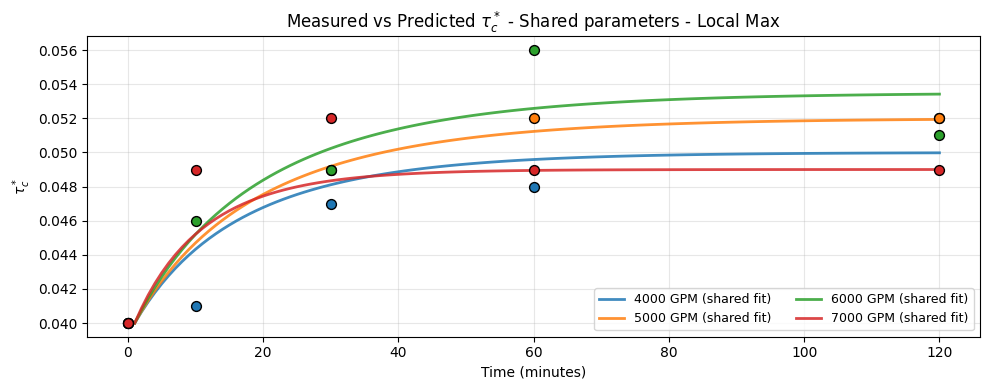

In [17]:
flows = ["4000", "5000", "6000", "7000"]
colors = dict(zip(flows, plt.cm.tab10.colors[:4]))

# use shared-parameter predictions
pred_by_flow = best_fit_shared

fig, ax = plt.subplots(figsize=(10, 4))

for flow in flows:
    if flow not in pred_by_flow or pred_by_flow[flow] is None:
        continue

    tau_series = tau_star[flow]
    pred_full = np.asarray(pred_by_flow[flow], dtype=float)

    c = colors[flow]
    ax.plot(
        tau_series.index,
        pred_full,
        color=c,
        linewidth=2,
        alpha=0.85,
        label=f"{flow} GPM (shared fit)"
    )

    obs = tauc_measurements[flow].to_numpy(dtype=float)
    obs_time = tauc_measurements.index.to_numpy()
    valid_obs_mask = ~np.isnan(obs)
    ax.scatter(
        obs_time[valid_obs_mask],
        obs[valid_obs_mask],
        color=c,
        s=50,
        edgecolors="black",
        zorder=3
    )

ax.set_xlabel("Time (minutes)")
ax.set_ylabel(r"$\tau_c^*$")
ax.set_title(r"Measured vs Predicted $\tau_c^*$ - Shared parameters - Local Max")
ax.grid(True, alpha=0.3)
ax.legend(ncol=2, fontsize=9, loc="lower right")
plt.tight_layout()
plt.show()

Global Max 

In [18]:
flows = ["4000", "5000", "6000", "7000"]

best_all, results_all = calibrate_parameters_all_flows(
    tau_star=tau_star,
    tauc_measurements=tauc_measurements,
    flows=flows,
    dt=1,
    k1_vals=k1_vals,
    k2_vals=k2_vals,
    eps_vals=eps_vals,
    gamma=2.5,
    bounds_mode="global",             
    aggregation="mean_of_flows",      # or "pooled"
    store_all_results=True,
    verbose=True,
)

print("Best shared parameters across all flows:")
print(best_all)

# optional: save the full search table
results_all.to_csv("results/iterations/all_flows_shared_iterations_globalmax.csv", index=False)

Progress: 12500/250000 (5.0%) | best MAE=0.007474
Progress: 25000/250000 (10.0%) | best MAE=0.007456
Progress: 37500/250000 (15.0%) | best MAE=0.007414
Progress: 50000/250000 (20.0%) | best MAE=0.007370
Progress: 62500/250000 (25.0%) | best MAE=0.007265
Progress: 75000/250000 (30.0%) | best MAE=0.007155
Progress: 87500/250000 (35.0%) | best MAE=0.006898
Progress: 100000/250000 (40.0%) | best MAE=0.006637
Progress: 112500/250000 (45.0%) | best MAE=0.006053
Progress: 125000/250000 (50.0%) | best MAE=0.005495
Progress: 137500/250000 (55.0%) | best MAE=0.004349
Progress: 150000/250000 (60.0%) | best MAE=0.003516
Progress: 162500/250000 (65.0%) | best MAE=0.002337
Progress: 175000/250000 (70.0%) | best MAE=0.002013
Progress: 187500/250000 (75.0%) | best MAE=0.001809
Progress: 200000/250000 (80.0%) | best MAE=0.001809
Progress: 212500/250000 (85.0%) | best MAE=0.001809
Progress: 225000/250000 (90.0%) | best MAE=0.001809
Progress: 237500/250000 (95.0%) | best MAE=0.001809
Progress: 250000/250

In [20]:
# run model for each flow using shared best params
best_fit_shared_global = run_best_fit_all_flows(
    tau_star=tau_star,
    tauc_measurements=tauc_measurements,
    flows=flows,
    best_params=best_all,
    dt=1,
    gamma=2.5,
    bounds_mode="global",
)
# export predicted tauc time series
predicted_tauc_df = pd.DataFrame({
    'Time': tau_c_pred_series.index,
    'Predicted_tauc': tau_c_pred_series.values
})
predicted_tauc_df.to_csv('results/predicted/all_global_predicted_tauc.csv', index=False)

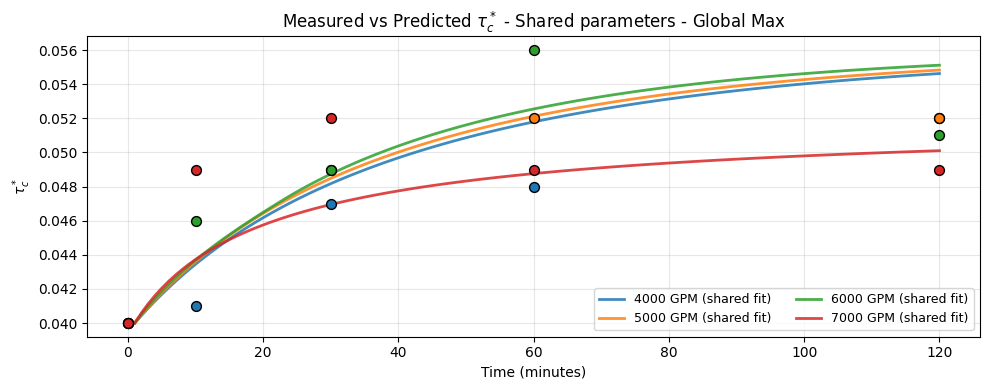

In [21]:
flows = ["4000", "5000", "6000", "7000"]
colors = dict(zip(flows, plt.cm.tab10.colors[:4]))

# use shared-parameter predictions
pred_by_flow = best_fit_shared_global

fig, ax = plt.subplots(figsize=(10, 4))

for flow in flows:
    if flow not in pred_by_flow or pred_by_flow[flow] is None:
        continue

    tau_series = tau_star[flow]
    pred_full = np.asarray(pred_by_flow[flow], dtype=float)

    c = colors[flow]
    ax.plot(
        tau_series.index,
        pred_full,
        color=c,
        linewidth=2,
        alpha=0.85,
        label=f"{flow} GPM (shared fit)"
    )

    obs = tauc_measurements[flow].to_numpy(dtype=float)
    obs_time = tauc_measurements.index.to_numpy()
    valid_obs_mask = ~np.isnan(obs)
    ax.scatter(
        obs_time[valid_obs_mask],
        obs[valid_obs_mask],
        color=c,
        s=50,
        edgecolors="black",
        zorder=3
    )

ax.set_xlabel("Time (minutes)")
ax.set_ylabel(r"$\tau_c^*$")
ax.set_title(r"Measured vs Predicted $\tau_c^*$ - Shared parameters - Global Max")
ax.grid(True, alpha=0.3)
ax.legend(ncol=2, fontsize=9, loc="lower right")
plt.tight_layout()
plt.show()